# Exemplo de Interseção: LiDAR × Inventário

Análise de um único plot de inventário com cobertura LiDAR.

**Site:** ANA_A01 (Anapu, PA) — **Plot:** 1

**Roteiro:**
1. Dados do inventário (árvores, espécies, DAP, biomassa estimada)
2. Sobreposição espacial: polígono do plot × tiles LiDAR que o cobrem
3. Referências: métricas LiDAR relevantes para predição de biomassa

## 0. Setup

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import laspy
from pyproj import Transformer

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

ROOT = Path('.').resolve()
for _ in range(5):
    if (ROOT / 'data').exists(): break
    ROOT = ROOT.parent

# Configuração do exemplo — altere para explorar outros sites/plots
SITE_CODE = 'ANA_A01'
PLOT_ID   = 1
INV_FILE  = 'ANA_A01_2015_2018_Inventory.csv'
UTM_EPSG  = 32718  # UTM zona 18S (WGS84)

INV_DIR      = next(p for p in (ROOT / 'data/raw/inventory').iterdir() if p.is_dir())
CLIPPED_DIR  = ROOT / 'data/processed/clipped_lidar'
INTER_CSV    = ROOT / 'data/processed/intersections/lidar_inventory_intersections.csv'

print('Pronto.')

Pronto.


## 1. Dados do inventário para o plot

In [7]:
inv_raw = pd.read_csv(INV_DIR / INV_FILE, encoding='latin-1', low_memory=False)

# Normaliza colunas
inv_raw.columns = [c.lower().replace('.','_').strip() for c in inv_raw.columns]

# Filtra o plot
plot_col = next((c for c in inv_raw.columns if 'plot' in c), None)
inv = inv_raw[inv_raw[plot_col] == PLOT_ID].copy() if plot_col else inv_raw.copy()

# DBH — pega a coluna mais recente
dbh_cols = sorted([c for c in inv.columns if 'dbh' in c], reverse=True)
if dbh_cols:
    inv['dbh'] = pd.to_numeric(inv[dbh_cols[0]], errors='coerce')

# Biomassa (Brown 1997)
if 'dbh' in inv.columns:
    ln_d = np.log(inv['dbh'].clip(lower=1))
    inv['agb_mg'] = np.exp(-2.289 + 2.649*ln_d - 0.021*ln_d**2) / 1000

print(f'Plot {PLOT_ID} — {len(inv)} árvores')
if 'dbh' in inv.columns:
    print(f'DAP: {inv["dbh"].min():.1f} – {inv["dbh"].max():.1f} cm  (mediana {inv["dbh"].median():.1f} cm)')
if 'agb_mg' in inv.columns:
    print(f'AGB total estimada: {inv["agb_mg"].sum():.2f} Mg')
if 'scientific_name' in inv.columns:
    print(f'Espécies: {inv["scientific_name"].nunique()}')

inv.head(10)

Plot 1 — 159 árvores
DAP: 10.1 – 59.6 cm  (mediana 15.9 cm)
AGB total estimada: 48.48 Mg
Espécies: 60


,area,plot,tree,common_name,scientific_name,family_name,type,dbh_2015,dead_2015,d_class_2015,...,re_2015,rw_2015,date_2015,dbh_2018,dead_2018,date_2018,utm_easting,utm_northing,dbh,agb_mg
0,ANA_A01,1,001a,jarana,Lecythis lurida,Lecythidaceae,O,18.7,False,NaN,...,NaN,NaN,20150715.0,18.8,False,20180913,721909.094803,9.627179e+06,18.8,0.200744
1,ANA_A01,1,001b,envira preta,Guatteria schomburgkiana,Annonaceae,O,17.5,False,NaN,...,NaN,NaN,20150715.0,20.9,False,20180913,721935.192304,9.627175e+06,20.9,0.262238
2,ANA_A01,1,002a,louro preto,Ocotea cernua,Lauraceae,O,15.2,False,NaN,...,NaN,NaN,20150715.0,15.3,False,20180913,721913.109804,9.627178e+06,15.3,0.119202
3,ANA_A01,1,002b,envira preta,Guatteria schomburgkiana,Annonaceae,O,15.5,False,NaN,...,NaN,NaN,20150715.0,17.8,False,20180913,721931.207423,9.627177e+06,17.8,0.174847
4,ANA_A01,1,003a,ucuuba vermelha,Virola elongata,Myristicaceae,O,18.8,False,NaN,...,NaN,NaN,20150715.0,19.0,False,20180913,721915.117304,9.627178e+06,19.0,0.206181
5,ANA_A01,1,003b,morta,NaN,NaN,O,10.1,True,2.0,...,NaN,NaN,20150715.0,NaN,True,20180913,721933.246572,9.627178e+06,NaN,NaN
6,ANA_A01,1,004a,inga branco,Inga thibaudiana,Fabaceae,O,13.0,False,NaN,...,NaN,NaN,20150715.0,16.6,False,20180913,721914.085435,9.627179e+06,16.6,0.146549
7,ANA_A01,1,004b,morta,NaN,NaN,O,12.7,True,2.0,...,NaN,NaN,20150715.0,NaN,True,20180913,721933.248859,9.627178e+06,NaN,NaN
8,ANA_A01,1,005a,jatereu,Lecythis idatimon,Lecythidaceae,O,10.3,False,NaN,...,NaN,NaN,20150715.0,10.2,False,20180913,721920.132589,9.627178e+06,10.2,0.042510
9,ANA_A01,1,005b,melancieira,Alexa grandiflora,Fabaceae,O,28.2,False,NaN,...,NaN,NaN,20150715.0,29.2,False,20180913,721928.255274,9.627182e+06,29.2,0.607947


### Distribuição de DAP e espécies do plot

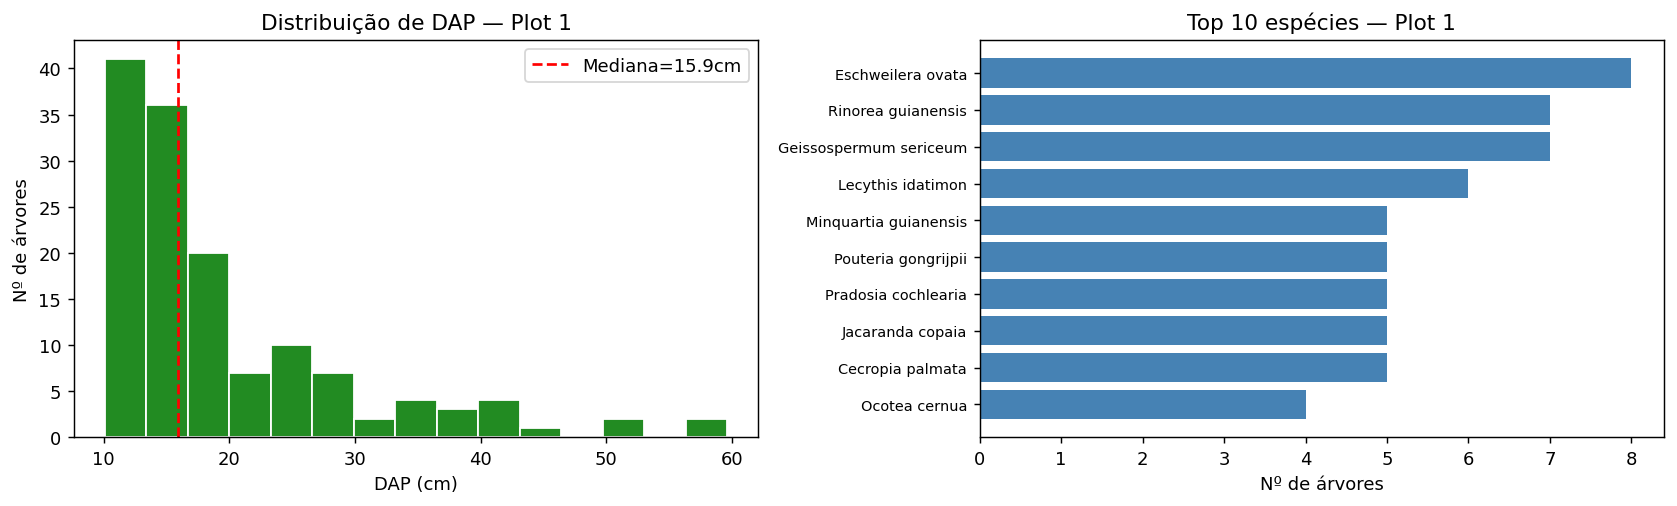

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if 'dbh' in inv.columns:
    dbh_valid = inv['dbh'].dropna()
    axes[0].hist(dbh_valid, bins=15, color='forestgreen', edgecolor='white')
    axes[0].axvline(dbh_valid.median(), linestyle='--', color='red', label=f'Mediana={dbh_valid.median():.1f}cm')
    axes[0].set_xlabel('DAP (cm)'); axes[0].set_ylabel('Nº de árvores')
    axes[0].set_title(f'Distribuição de DAP — Plot {PLOT_ID}')
    axes[0].legend()

sp_col = next((c for c in inv.columns if 'scientific' in c), None)
if sp_col:
    top_sp = inv[sp_col].value_counts().head(10)
    axes[1].barh(top_sp.index[::-1], top_sp.values[::-1], color='steelblue')
    axes[1].set_xlabel('Nº de árvores')
    axes[1].set_title(f'Top 10 espécies — Plot {PLOT_ID}')
    axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

## 2. Sobreposição espacial: plot de inventário × tiles LiDAR

Plot:         ANA_A01 / 1
Tiles LiDAR que cobrem este plot: 3
Área do plot (bbox): (-55.00282173998435, -3.370999544911888, -55.00232556004358, -3.370535257881526)


/tmp/ipykernel_2962520/2271980464.py:75: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


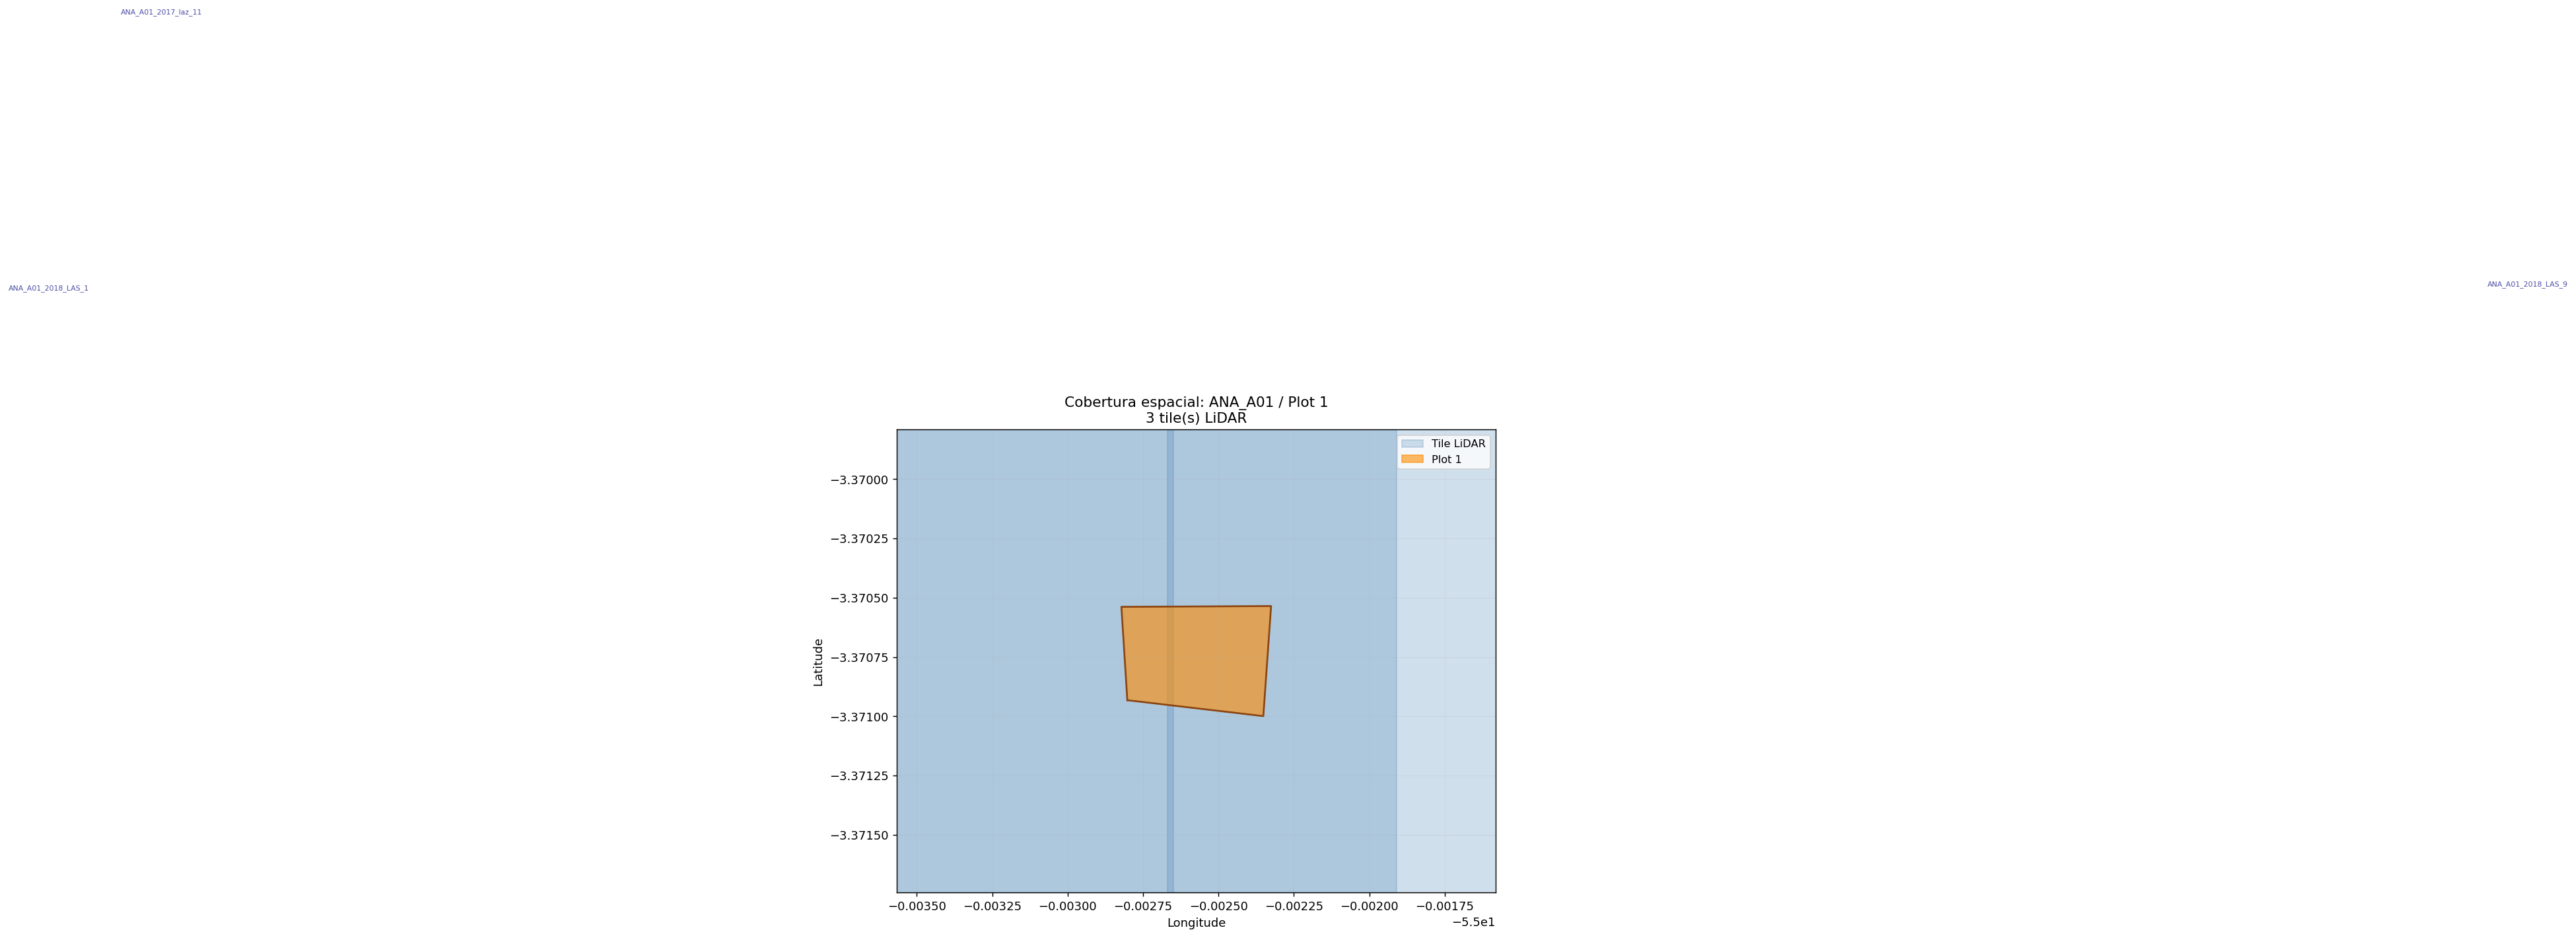

In [9]:
import geopandas as gpd
import matplotlib.patches as mpatches
from shapely.geometry import box as shapely_box

KML_DIR   = ROOT / 'data/processed/kml'
LIDAR_CSV = next(p for p in (ROOT / 'data/raw/lidar').iterdir() if p.is_dir()) / 'cms_brazil_lidar_tile_inventory.csv'

# Polígono do plot de inventário (do KML)
kml_file = next(KML_DIR.glob(f'{SITE_CODE}*.kml'))
gdf_plots = gpd.read_file(kml_file, driver='KML').set_crs('EPSG:4326')
plot_geom = gdf_plots[gdf_plots['Name'].astype(str) == str(PLOT_ID)].geometry.iloc[0]

# Tiles LiDAR que cobrem este plot (do CSV de interseções)
inter = pd.read_csv(INTER_CSV)
site_inter_file = next(
    f for f in inter['inventory_file'].unique()
    if SITE_CODE in f
)
tile_names = inter[
    (inter['inventory_file'] == site_inter_file) &
    (inter['plot_id'].astype(str) == str(PLOT_ID))
]['laz_file'].tolist()

df_lidar = pd.read_csv(LIDAR_CSV)
tiles = df_lidar[df_lidar['filename'].isin(tile_names)]

print(f'Plot:         {SITE_CODE} / {PLOT_ID}')
print(f'Tiles LiDAR que cobrem este plot: {len(tiles)}')
print(f'Área do plot (bbox): {plot_geom.bounds}')

# ── Visualização ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Tiles LiDAR (retângulos azuis)
for _, t in tiles.iterrows():
    w = t['max_lon'] - t['min_lon']
    h = t['max_lat'] - t['min_lat']
    rect = mpatches.Rectangle(
        (t['min_lon'], t['min_lat']), w, h,
        linewidth=1, edgecolor='steelblue', facecolor='steelblue', alpha=0.25,
        label='Tile LiDAR'
    )
    ax.add_patch(rect)
    ax.text(t['min_lon'] + w/2, t['min_lat'] + h/2,
            t['filename'].replace('.laz',''), fontsize=6, ha='center', color='navy', alpha=0.7)

# Polígono do plot de inventário (laranja)
if plot_geom.geom_type == 'Polygon':
    xs, ys = plot_geom.exterior.xy
    ax.fill(xs, ys, alpha=0.6, color='darkorange', label=f'Plot inventário {PLOT_ID}')
    ax.plot(xs, ys, color='saddlebrown', linewidth=1.5)
else:
    for geom in plot_geom.geoms:
        xs, ys = geom.exterior.xy
        ax.fill(xs, ys, alpha=0.6, color='darkorange', label=f'Plot {PLOT_ID}')
        ax.plot(xs, ys, color='saddlebrown', linewidth=1.5)

# Ajusta limites com margem
bounds = plot_geom.bounds  # (minx, miny, maxx, maxy)
pad = max((bounds[2]-bounds[0]), (bounds[3]-bounds[1])) * 1.5
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

# Legenda única (sem duplicatas)
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), fontsize=9)

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Cobertura espacial: {SITE_CODE} / Plot {PLOT_ID}\n{len(tiles)} tile(s) LiDAR')
ax.grid(True, linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Relação entre métricas LiDAR e biomassa

### Métricas chave para predição de AGB

| Métrica LiDAR | Relação com biomassa | Referência |
|---|---|---|
| `h_p95` (altura P95) | Proxy da altura máxima do dossel — forte correlação com AGB | Lefsky et al. 2002 |
| `h_mean` (altura média) | Correlaciona com estrutura do dossel | Drake et al. 2002 |
| `canopy_cover` (cobertura > 2m) | Indica densidade de copa | Asner et al. 2012 |
| `h_cv` (coeficiente de variação) | Heterogeneidade vertical — árvores emergentes vs. sub-bosque | |
| `density_pts_m2` | Qualidade do dado — mínimo ~4 pts/m² para métricas confiáveis | |

### Próximo passo

Aplicar essa extração de métricas a **todos os 108 plots com cobertura LiDAR** (`data/processed/clipped_lidar/`) e cruzar com as AGB do inventário para treinar o modelo de predição.

In [10]:
print('=== Resumo do plot ===')
print(f'Site: {SITE_CODE}  |  Plot: {PLOT_ID}')
print(f'\n--- Inventário ---')
print(f'Árvores:        {len(inv)}')
if 'dbh' in inv.columns:
    print(f'DAP mediano:    {inv["dbh"].median():.1f} cm')
    print(f'DAP máximo:     {inv["dbh"].max():.1f} cm')
if 'agb_mg' in inv.columns:
    print(f'AGB estimada:   {inv["agb_mg"].sum():.2f} Mg')

print(f'\n--- Cobertura LiDAR ---')
print(f'Tiles que cobrem o plot: {len(tiles)}')
for _, t in tiles.iterrows():
    area_km2 = (t['max_lon']-t['min_lon']) * (t['max_lat']-t['min_lat']) * 111**2
    print(f'  {t["filename"]}  ({area_km2:.3f} km²  |  zona {t["utmzone"]})')

=== Resumo do plot ===
Site: ANA_A01  |  Plot: 1

--- Inventário ---
Árvores:        159
DAP mediano:    15.9 cm
DAP máximo:     59.6 cm
AGB estimada:   48.48 Mg

--- Cobertura LiDAR ---
Tiles que cobrem o plot: 3
  ANA_A01_2017_laz_11.laz  (0.914 km²  |  zona 21S)
  ANA_A01_2018_LAS_1.laz  (0.832 km²  |  zona 21S)
  ANA_A01_2018_LAS_9.laz  (1.006 km²  |  zona 21S)


## 6. Mais exemplos de interseção

Cobertura espacial para três outros sites, ilustrando situações distintas:

| Site | Plot | Tiles | Detalhe |
|---|---|---|---|
| AND_A01 (Andirá, AM) | 1 | 3 | Mesma bbox coberta por dois voos distintos (2013 e 2017) — sobreposição temporal total |
| HUM_A01 (Humaitá, AM) | 1 | 2 | Dois voos parcialmente sobrepostos (2013 e 2018), UTM 19S |
| TAC_A01 (Tucuruí, PA) | 1 | 1 | Caso simples: um único tile cobre o plot, UTM 22S |

In [ ]:
EXAMPLES = [
    dict(site='AND_A01', plot_id=1, inv_file='AND_A01_2013_2018_Inventory.csv',
         inter_key='AND_A01_2013_2018_inventory_plots', kml='AND_A01_2013_2018_inventory_plots.kml'),
    dict(site='HUM_A01', plot_id=1, inv_file='HUM_A01_2014_Inventory.csv',
         inter_key='HUM_A01_2014_inventory_plots',      kml='HUM_A01_2014_inventory_plots.kml'),
    dict(site='TAC_A01', plot_id=1, inv_file='TAC_A01_2015_Inventory.csv',
         inter_key='TAC_A01_2015_inventory_plots',      kml='TAC_A01_2015_inventory_plots.kml'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ex in zip(axes, EXAMPLES):
    site    = ex['site']
    plot_id = ex['plot_id']

    # Inventário
    inv_raw = pd.read_csv(INV_DIR / ex['inv_file'], encoding='latin-1', low_memory=False)
    inv_raw.columns = [c.lower().replace('.', '_').strip() for c in inv_raw.columns]
    plot_col = next((c for c in inv_raw.columns if 'plot' in c), None)
    inv_sub  = inv_raw[inv_raw[plot_col].astype(str) == str(plot_id)].copy() if plot_col else inv_raw.copy()
    dbh_cols = sorted([c for c in inv_raw.columns if 'dbh' in c], reverse=True)
    if dbh_cols:
        inv_sub['dbh'] = pd.to_numeric(inv_sub[dbh_cols[0]], errors='coerce')

    # Polígono do plot (KML explícito)
    gdf       = gpd.read_file(KML_DIR / ex['kml'], driver='KML').set_crs('EPSG:4326')
    plot_geom = gdf[gdf['Name'].astype(str) == str(plot_id)].geometry.iloc[0]

    # Tiles LiDAR
    tile_names = inter[
        (inter['inventory_file'] == ex['inter_key']) &
        (inter['plot_id'].astype(str) == str(plot_id))
    ]['laz_file'].tolist()
    tiles_ex = df_lidar[df_lidar['filename'].isin(tile_names)]

    # ── Desenha tiles ──
    for _, t in tiles_ex.iterrows():
        w = t['max_lon'] - t['min_lon']
        h = t['max_lat'] - t['min_lat']
        rect = mpatches.Rectangle(
            (t['min_lon'], t['min_lat']), w, h,
            linewidth=1, edgecolor='steelblue', facecolor='steelblue', alpha=0.25,
            label='Tile LiDAR'
        )
        ax.add_patch(rect)
        ax.text(t['min_lon'] + w / 2, t['min_lat'] + h / 2,
                t['filename'].replace('.laz', ''), fontsize=5, ha='center', color='navy', alpha=0.7)

    # ── Desenha polígono do plot ──
    geoms = [plot_geom] if plot_geom.geom_type == 'Polygon' else list(plot_geom.geoms)
    for geom in geoms:
        xs, ys = geom.exterior.xy
        ax.fill(xs, ys, alpha=0.6, color='darkorange', label=f'Plot {plot_id}')
        ax.plot(xs, ys, color='saddlebrown', linewidth=1.5)

    # ── Limites e decoração ──
    bounds = plot_geom.bounds
    pad = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 1.5
    ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    ax.set_ylim(bounds[1] - pad, bounds[3] + pad)
    ax.ticklabel_format(useOffset=False, style='plain')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        if l not in seen:
            seen[l] = h
    ax.legend(seen.values(), seen.keys(), fontsize=8)

    ax.set_title(f'{site} / Plot {plot_id}\n{len(tiles_ex)} tile(s) LiDAR  |  {len(inv_sub)} árvores', fontsize=9)
    ax.set_xlabel('Longitude', fontsize=8)
    ax.set_ylabel('Latitude', fontsize=8)
    ax.grid(True, linewidth=0.3, alpha=0.4)

plt.suptitle('Cobertura LiDAR × parcelas de inventário — mais exemplos', fontsize=11)
plt.tight_layout()
plt.show()